# 🧩 Unsupervised Learning: Clustering & Dimensionality Reduction
In this notebook, we act as if we don't know the labels of our data. We will ask the algorithms to find natural groupings and reduce complex dimensions so we can visualize them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# 1. Load Data (We will pretend we don't have the target labels!)
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# 2. Scale Data (CRITICAL for K-Means and PCA because they rely on distance/variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data Shape: {X_scaled.shape} (4 Dimensions)")

Data Shape: (150, 4) (4 Dimensions)


## Part 1: Dimensionality Reduction (PCA)
Our data has 4 dimensions (sepal length, sepal width, petal length, petal width). Humans can't see in 4D. We will use Principal Component Analysis (PCA) to compress this into 2 Dimensions while retaining maximum information.

New Data Shape: (150, 2) (2 Dimensions)
Variance retained: 95.81%


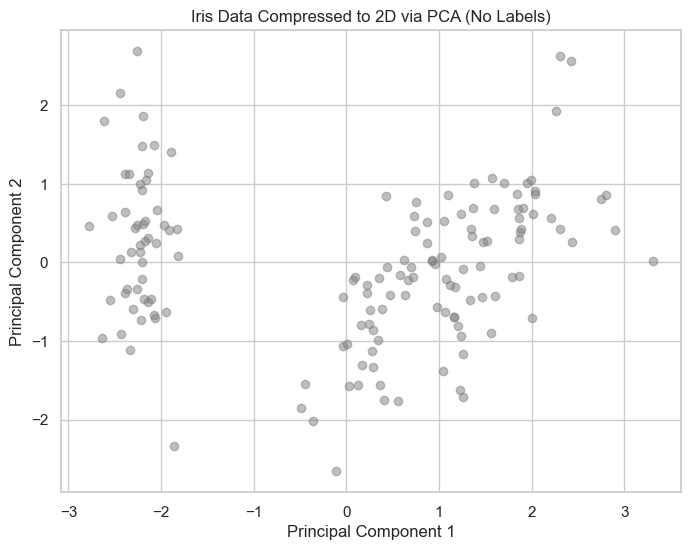

In [2]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"New Data Shape: {X_pca.shape} (2 Dimensions)")
print(f"Variance retained: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

# Let's visualize the raw 2D data before we cluster it
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.5)
plt.title('Iris Data Compressed to 2D via PCA (No Labels)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Part 2: Clustering (K-Means)
Looking at the plot above, we can visually see groupings. Let's use K-Means to mathematically assign these points to 3 clusters.

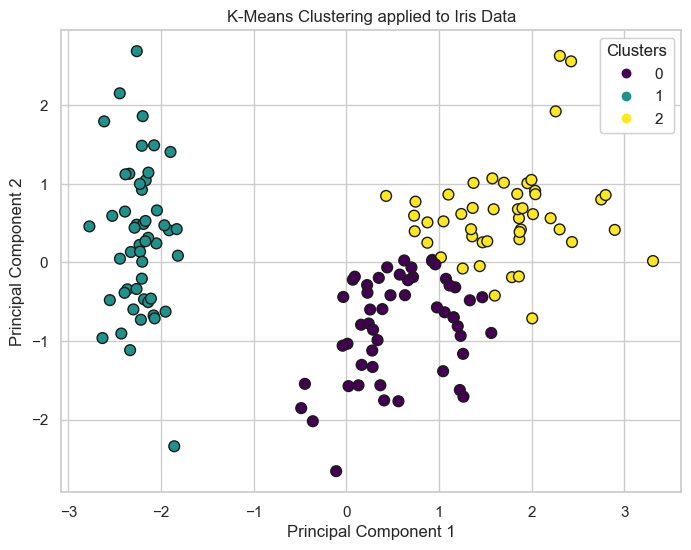

In [3]:
from sklearn.cluster import KMeans

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Let's visualize the PCA data again, but this time colored by the K-Means clusters!
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k', s=60)
plt.title('K-Means Clustering applied to Iris Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Adding a legend
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.show()

## Bonus: Evaluating K-Means (The Elbow Method)
How did we know 3 was the right number of clusters? We can plot the Within-Cluster-Sum-of-Squares (WCSS) to find the "Elbow".

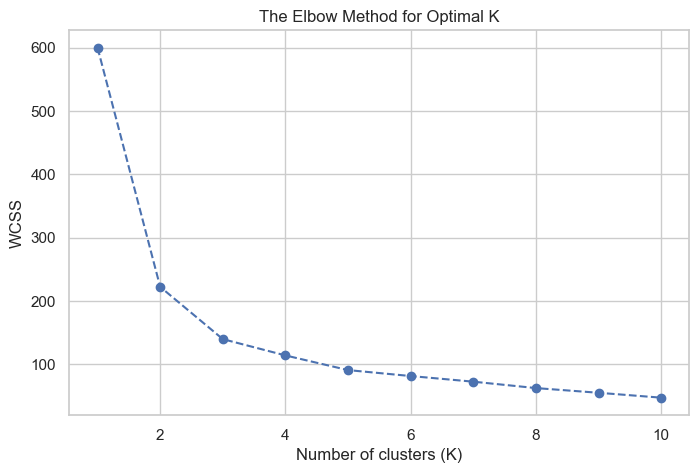

Notice how the elbow clearly bends at K=3!


In [4]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

print("Notice how the elbow clearly bends at K=3!")